In [1]:
import os as os
import pandas as pd
import numpy as np
from scipy import stats
from scipy import special
from scipy.optimize import linear_sum_assignment
from MLstatkit.stats import Delong_test

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns



### Data Preparation

In [2]:
featuresGTV_df = pd.read_excel("features_GTVSelected.xlsx", index_col=0)
featuresTRAD_df = pd.read_excel("features_TRADSelected.xlsx", index_col=0)

In [3]:
FEATURES = [feat for feat in featuresGTV_df.columns if "original" in feat]

### Feature Filtering

Removing features with near 0 variance

In [4]:

def filter_near_zero(df, threshold = 1e-3):
    feats = df.columns.to_list()
    feats_var = df.var()
    mask_feats = feats_var[feats_var<=threshold].index.to_list()
    selected_feats = [feat for feat in feats if feat not in mask_feats]
    print(f"Deleted {len(mask_feats)}/{len(feats)} near zero features, remaining {len(selected_feats)} features")
    return selected_feats

Removing highly correlated features

In [5]:
def filter_high_corr(df, threshold=0.85):

    corr_matrix = df.corr(method='spearman').abs()
    mean_corr = corr_matrix.mean()
    ordered_feats = mean_corr.sort_values(ascending=True).index.to_list()

    corr_matrix = df[ordered_feats].corr(method='spearman').abs()
    up_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    mask_feats = [column for column in up_tri.columns if any(up_tri[column]>=threshold)]
    selected_feats = [feat for feat in ordered_feats if feat not in mask_feats]
    print(f"Deleted {len(mask_feats)}/{len(ordered_feats)} highly corr features, remaining {len(selected_feats)} features")
    
    return selected_feats

In [6]:
filtered_features = filter_near_zero(featuresTRAD_df[FEATURES])
FILTERED_FEATURES_TRAD = filter_high_corr(featuresTRAD_df[filtered_features])

Deleted 4/107 near zero features, remaining 103 features
Deleted 75/103 highly corr features, remaining 28 features


In [7]:
filtered_features = filter_near_zero(featuresGTV_df[FEATURES])
FILTERED_FEATURES_GTV = filter_high_corr(featuresGTV_df[filtered_features])

Deleted 4/107 near zero features, remaining 103 features
Deleted 81/103 highly corr features, remaining 22 features


### Feature Selection & Modelling

Mann-Whitney U-test

In [8]:
def mannwhitneyu(X_df, y_df, num_feats=3):
    
    features = X_df.columns.to_list()
    
    pval_df = {}
    
    for feat in features:

        x = X_df[feat]
        u, p = stats.mannwhitneyu(x[y_df==0], x[y_df==1])
        
        auc = u/(len(x)*len(y_df))
        
        pval_df.setdefault("feature",[]).append(feat)
        pval_df.setdefault("p_value",[]).append(p)
        pval_df.setdefault("roc_auc", []).append(max(auc, 1-auc))
    
    pval_df = pd.DataFrame(pval_df).sort_values(by="p_value").reset_index(drop=True)
    
    return pval_df.feature.to_list()[:num_feats]

In [9]:
from sklearn.model_selection import RepeatedStratifiedKFold


def sequential_selector(X_df, y_df, piped_estimator, num_feats=3, n_splits = 10, direction='backward', metric='roc_auc'):
     
    features = X_df.columns.to_list()
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=100)
    sfs = SequentialFeatureSelector(piped_estimator, n_features_to_select=num_feats, direction=direction, scoring=metric, cv=cv, n_jobs=-1) #by default SFS will do stratified cross validation for classification problem
    sfs.fit(X_df, y_df)
    
    selected_features = np.array(features)[sfs.get_support()]
    
    return list(selected_features)


### SFS based Selection + Prediction

In [10]:
if not os.path.exists(os.path.join("new_results/cv10_selected_signature.npy")):

    models = {
        'LR': LogisticRegression(penalty='none', max_iter=25_000),
        'L-SVM': SVC(probability=True),
        'RF': RandomForestClassifier(random_state=0)
        }

    cv = StratifiedKFold(n_splits=10, shuffle=False)

    selected_signature = {"gtv":{}, "trad":{}}

    for roi_name, value_dict in {"gtv":{"df":featuresGTV_df, "features":FILTERED_FEATURES_GTV}, "trad":{"df":featuresTRAD_df, "features":FILTERED_FEATURES_TRAD}}.items():
        print("*"*10)
        print(roi_name)
        print("*"*10)
        
        df = value_dict["df"]
        features = value_dict["features"]
        for model_name, model in models.items():
            piped_model = make_pipeline(StandardScaler(), model)
            print(f"Evaluating {model_name} on {roi_name} dataset...")
            
            selected_features = sequential_selector(df[features], df["PD"], piped_model, num_feats=3)
            selected_signature[roi_name][model_name] = selected_features
            
            X_df = df[selected_features]
            y_df = df["PD"]
            
            cv_aucs = cross_val_score(piped_model, X_df, y_df, cv=cv, scoring='roc_auc')
            
            print(cv_aucs.mean())

            
    np.save(os.path.join("new_results", "cv10_selected_signature.npy"), selected_signature, allow_pickle=True)

else:
    selected_signature = np.load(os.path.join("new_results", "cv10_selected_signature.npy"), allow_pickle=True).item()

In [11]:
selected_signature

{'gtv': {'LR': ['original_glszm_SizeZoneNonUniformityNormalized',
   'original_gldm_LargeDependenceHighGrayLevelEmphasis',
   'original_gldm_DependenceVariance'],
  'L-SVM': ['original_glcm_MCC',
   'original_glcm_Imc1',
   'original_glszm_GrayLevelVariance'],
  'RF': ['original_shape_Flatness',
   'original_shape_MajorAxisLength',
   'original_ngtdm_Busyness']},
 'trad': {'LR': ['original_glcm_Imc1',
   'original_firstorder_InterquartileRange',
   'original_glcm_Imc2'],
  'L-SVM': ['original_firstorder_Median',
   'original_gldm_LargeDependenceLowGrayLevelEmphasis',
   'original_gldm_DependenceEntropy'],
  'RF': ['original_glcm_Imc1',
   'original_shape_MajorAxisLength',
   'original_glcm_MaximumProbability']}}

In [ ]:
# ### Mann-Whitney U-Test Selection + Prediction

# uselected_signature = {"gtv":{}, "trad":{}}

# for roi_name, value_dict in {"gtv":{"df":featuresGTV_df, "features":FILTERED_FEATURES_GTV}, "trad":{"df":featuresTRAD_df, "features":FILTERED_FEATURES_TRAD}}.items():
#     print("*"*10)
#     print(roi_name)
#     print("*"*10)
    
#     df = value_dict["df"]
#     features = value_dict["features"]
#     for model_name, model in models.items():
#         piped_model = make_pipeline(StandardScaler(), model)
#         print(f"Evaluating {model_name} on {roi_name} dataset...")
        
#         selected_features = mannwhitneyu(df[features], df["PD"], num_feats=3)
#         uselected_signature[roi_name][model_name] = selected_features
        
#         X_df = df[selected_features]
#         y_df = df["PD"]
        
#         cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10)
#         cv_aucs = cross_val_score(piped_model, X_df, y_df, cv=cv, scoring='roc_auc')
        
#         print(cv_aucs.mean())
#         # results_sfs_GTV.append({
#         #     'Model': model_name,
#         #     'Selected Features': ', '.join(selected_features_GTV),
#         #     'AUC per fold': auc_sfs.tolist(),
#         #     'Media AUC': auc_sfs.mean()
#         # })


### Result Visualizations

In [49]:

def plot_cvroc(classifier, X_df, y_df, cv, ax, label=None):
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X_df, y_df):
        classifier.fit(X_df.iloc[train_idx], y_df.iloc[train_idx])
        y_prob = classifier.predict_proba(X_df.iloc[test_idx])[:, 1]

        # Compute ROC for this fold
        fpr_fold, tpr_fold, _ = roc_curve(y_df.iloc[test_idx], y_prob)

        # Interpolate TPR
        interp_tpr = np.interp(mean_fpr, fpr_fold, tpr_fold)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

        # AUC for this fold
        aucs.append(auc(fpr_fold, tpr_fold))
        
        

    # Mean ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    
    # std_tpr = np.std(tprs, axis=0)
    # tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    # tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    # ax.fill_between(
    #     mean_fpr,
    #     tprs_lower,
    #     tprs_upper,
    #     color="grey",
    #     alpha=0.2,
    #     label=r"$\pm$ 1 std. dev.",
    # )
    


    ax.plot(
        mean_fpr,
        mean_tpr,
        lw=2,
        alpha=0.8,
        label=f"{label} (AUC = {mean_auc:.2f} ± {std_auc:.2f})"
    )


**********
gtv
**********
estimator: LR
estimator: L-SVM
estimator: RF
**********
trad
**********
estimator: LR
estimator: L-SVM
estimator: RF


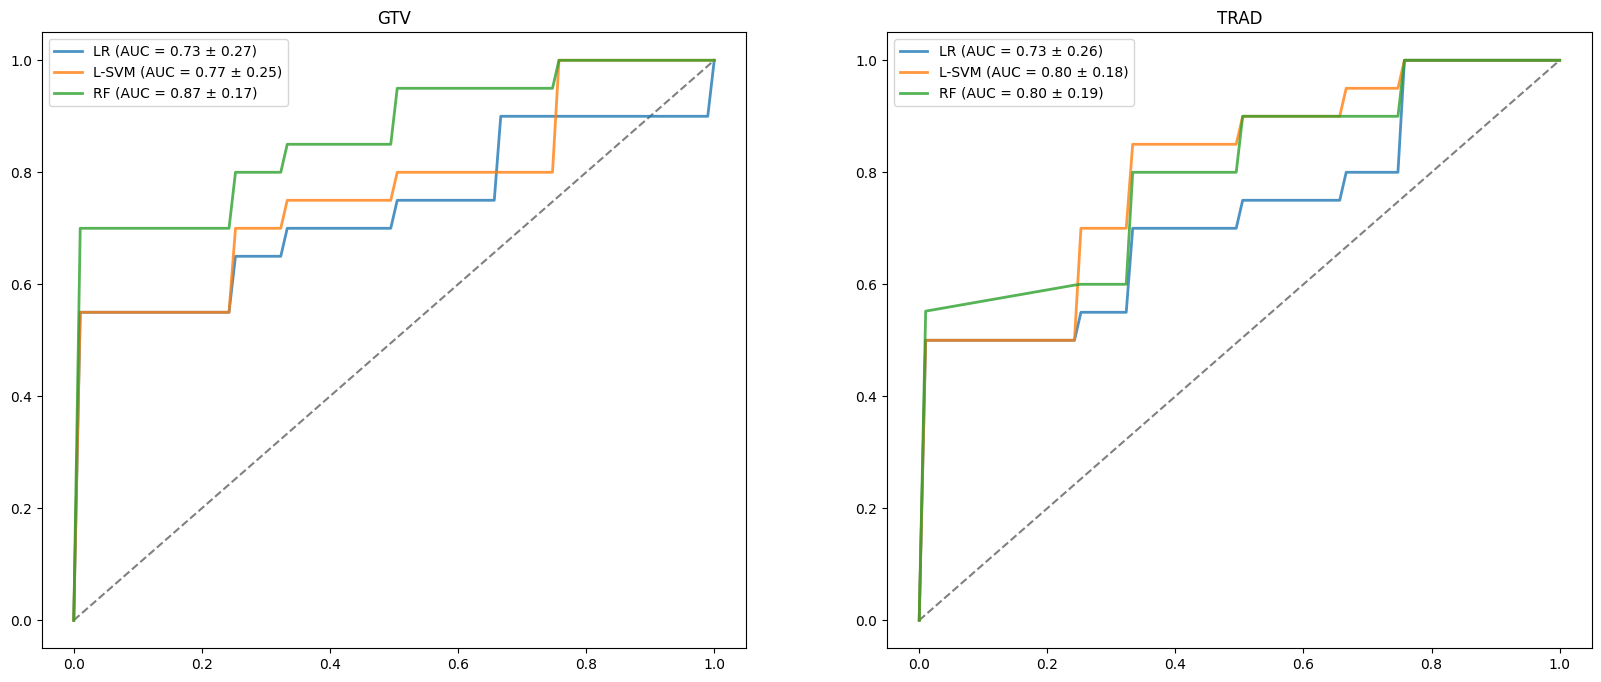

In [ ]:
models = {
        'LR': LogisticRegression(penalty='none', max_iter=25_000),
        'L-SVM': SVC(probability=True),
        'RF': RandomForestClassifier(random_state=0)
        }


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

roi_names = ["gtv", "trad"]

for roi_name, df in {"gtv":featuresGTV_df, "trad":featuresTRAD_df}.items():
    
    ax = axes[roi_names.index(roi_name)]
    ax.set_title(roi_name.upper())
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    
    
    print("*"*10)
    print(roi_name)
    print("*"*10)
    
    cv = StratifiedKFold(n_splits=10, shuffle=False)
    
    for estimator_name, estimator in models.items():
        selected_features = selected_signature[roi_name][estimator_name]
        piped_estimator = make_pipeline(StandardScaler(), estimator)
        
        X_df = df[selected_features]
        y_df = df["PD"]
        
        print(f"estimator: {estimator_name}")
        plot_cvroc(piped_estimator, X_df, y_df, cv = cv, ax=ax, label=estimator_name)
        
    ax.legend()
        




### Statistical Analysis

In [ ]:
def get_bootstrap_sample(X_df, y_df, n_splits):
    """
    Returns a stratified bootstrap sample of X and y,
    preserving class proportions.
    """
    
    df = pd.concat([X_df, y_df], axis=1)
    
    while True:
        sampled_df = df.sample(n=len(df), replace=True).reset_index(drop=True)
        if sampled_df[y_df.name].sum()>=n_splits:
            break;

    return sampled_df[X_df.columns], sampled_df[y_df.name]


def percentile_bootstrap_ci(X_df, y_df, statistic, n_splits, n_iterations, alpha=0.05):
    
    true_statistic = statistic(X_df, y_df)
    
    assert np.isscalar(true_statistic), "the statistic method should return a scalar value"
    
    bootstrap_statistics = []
    
    for i in range(n_iterations):
        
        X_sample, y_sample = get_bootstrap_sample(X_df, y_df, n_splits) 
        estimate = statistic(X_sample, y_sample)
        bootstrap_statistics.append(estimate)


    ci_boot = np.percentile(bootstrap_statistics, [(alpha*100)/2, 100-((alpha*100)/2)])
    
    return true_statistic, ci_boot, bootstrap_statistics

def bca_bootstrap_ci(X_df, y_df, statistic, bootstrap_statistics, alpha=0.05): #bias corrected and accelerated
    """
    Calculate Bias corrected and accelerated confidence intervals for a bootstrap distribution.
    
    https://www.tau.ac.il/~saharon/Boot/10.1.1.133.8405.pdf
    
    equations: https://www.erikdrysdale.com/bca_python/
    
    Parameters:
        X_df the dataframe with features
        y_df the pandas series with values
        statistic: the function that will return a scalar estimate of the statistic of interest
        bootstrapped_statistics: Array of bootstrap statistics.
        alpha: Significance level (default 0.05 for 95% CI).
    
    Returns:
        Lower and upper bounds of the confidence interval.
    """
    # Sort the bootstrap statistics
    
    true_statistic = statistic(X_df, y_df)
    assert np.isscalar(true_statistic), "the statistic function should return a scalar value"
    
    # bootstrap_statistics = np.append(bootstrap_statistics, true_statistic) 
    bootstrap_statistics = np.sort(bootstrap_statistics)
    B = len(bootstrap_statistics)

    # Bias correction factor (z0)
    # https://github.com/scipy/scipy/blob/v1.16.2/scipy/stats/_resampling.py#L73
    ## Option 1
    prop = ((bootstrap_statistics < true_statistic).sum() + (bootstrap_statistics <= true_statistic).sum()) / (2*B) 
    prop = np.clip(prop, 0.1, 0.9) #this prevent weird answers for extremely skewed bootstrap distributions
    z0 = special.ndtri(prop)
    
    ##Option 2
    # prop = np.mean(bootstrap_statistics < true_statistic)
    # z0 = special.ndtri(prop)
    
    # Acceleration constant (a)
    # jackknife estimates (leave one out)
    jackknife_estimates = np.array([statistic(X_df.drop(index=i, inplace=False), y_df.drop(index=i, inplace=False)) 
                                    for i in X_df.index])
    mean_jackknife = np.mean(jackknife_estimates)
    
    num = np.sum((mean_jackknife - jackknife_estimates) ** 3)
    den = (6 * np.sum((mean_jackknife - jackknife_estimates) ** 2) ** 1.5)
    a =  num/den if den!=0 else 0.0 

    ## Option 1: Adjusted percentiles
    # z_alpha_low = stats.norm.ppf(alpha / 2)  # Lower z-score
    # z_alpha_high = stats.norm.ppf(1 - alpha / 2)  # Upper z-score
    
    # lower_percentile = stats.norm.cdf(z0 + ((z0 + z_alpha_low) / (1 - a * (z0 + z_alpha_low))))
    # upper_percentile = stats.norm.cdf(z0 + ((z0 + z_alpha_high) / (1 - a * (z0 + z_alpha_high))))
    
    # ci = np.quantile(bootstrap_statistics, [lower_percentile, upper_percentile])
    
    ## Option 2:
    z_alpha = special.ndtri(alpha)
    z_1alpha = -z_alpha
    
    num1 = z0 + z_alpha
    alpha_1 = special.ndtr(z0 + num1/(1 - a*num1))
    num2 = z0 + z_1alpha
    alpha_2 = special.ndtr(z0 + num2/(1 - a*num2))
    
    ci = np.quantile(bootstrap_statistics, [alpha_1, alpha_2])

   

    # Map percentiles to bootstrap statistics
    

    return true_statistic, ci, bootstrap_statistics



def permutation_test(X_df, y_df, statistic, n_iterations):
    
    true_statistic = statistic(X_df, y_df)
    perm_statistics = [true_statistic]
    
    for i in range(n_iterations-1):
        perm_y_df = y_df.sample(frac=1).reset_index(drop=True)
        estimate = statistic(X_df, perm_y_df)
        
        perm_statistics.append(estimate)
        
    return np.mean(np.abs(perm_statistics)>=np.abs(true_statistic)), perm_statistics    


def compare_aucs(probs1, probs2, targets):

    z_score, p_value = Delong_test(targets, probs1, probs2)
    
    return p_value
    




In [17]:
def cross_val_metric(piped_model, cv, metric):
    def call_fn(X_df, y_df):
        return np.mean(cross_val_score(piped_model, X_df, y_df, scoring=metric, cv=cv))
    return call_fn


In [16]:
boot_dist = np.load(r"new_results/boot_dist.npy", allow_pickle=True).item()

In [30]:

n_iterations = 20_000

models = {
    'LR': LogisticRegression(penalty='none', max_iter=25_000),
    'L-SVM': SVC(probability=True),
    'RF': RandomForestClassifier(random_state=0)
    }

for roi_name, df in {"trad":featuresTRAD_df, "gtv":featuresGTV_df}.items():

    cv = StratifiedKFold(n_splits=10, shuffle=False)
    metric = 'roc_auc'
    
    print("*"*10)
    print(roi_name)
    print("*"*10)
    
    for model_name, model in models.items():
        
        print(f"Evaluating {model_name} on {roi_name} dataset...")
        piped_model = make_pipeline(StandardScaler(), model)
        
        selected_features = selected_signature[roi_name][model_name]
        
        print("Features:")
        print(selected_features)
        
        X_df = df[selected_features]
        y_df = df['PD']
        
        # true_estimate, percentile_ci, boot_values = percentile_bootstrap_ci(X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric="roc_auc"), n_splits = cv.n_splits, n_iterations=n_iterations)
        # print("percentile ci:", true_estimate, percentile_ci, np.mean(boot_values))
        boot_values = boot_dist[roi_name][model_name]
        true_estimate, bca_ci, _ = bca_bootstrap_ci(X_df, y_df, statistic=cross_val_metric(piped_model, cv = cv, metric=metric), bootstrap_statistics=boot_values)
        # p, bca_ci = bca_bootstrap_ci_mlab(X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric=metric), boot=boot_values)
        print("bca ci:", bca_ci)
        

**********
trad
**********
Evaluating LR on trad dataset...
Features:
['original_glcm_Imc1', 'original_firstorder_InterquartileRange', 'original_glcm_Imc2']
bca ci: [0.54830398 0.8625    ]
Evaluating L-SVM on trad dataset...
Features:
['original_firstorder_Median', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_gldm_DependenceEntropy']
bca ci: [0.6875     0.92777778]
Evaluating RF on trad dataset...
Features:
['original_glcm_Imc1', 'original_shape_MajorAxisLength', 'original_glcm_MaximumProbability']
bca ci: [0.71875    0.90694444]
**********
gtv
**********
Evaluating LR on gtv dataset...
Features:
['original_glszm_SizeZoneNonUniformityNormalized', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_gldm_DependenceVariance']
bca ci: [0.52083333 0.83857089]
Evaluating L-SVM on gtv dataset...
Features:
['original_glcm_MCC', 'original_glcm_Imc1', 'original_glszm_GrayLevelVariance']
bca ci: [0.45444163 0.84166667]
Evaluating RF on gtv dataset...
Features:
['orig

(array([   7.,    5.,   17.,   64.,  223.,  536., 1467., 2475., 3054.,
        2153.]),
 array([0.71875 , 0.746875, 0.775   , 0.803125, 0.83125 , 0.859375,
        0.8875  , 0.915625, 0.94375 , 0.971875, 1.      ]),
 <BarContainer object of 10 artists>)

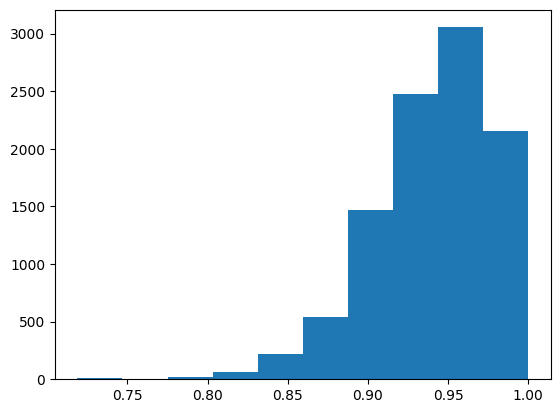

In [21]:
plt.hist(boot_values)

In [ ]:

n_iterations = 10
cv = StratifiedKFold(n_splits=10, shuffle=False)
metric = "roc_auc"
num_feats = 3


perm_dist = {"gtv":{}, "trad":{}}
boot_dist = {"gtv":{}, "trad":{}}

models = {
    'LR': LogisticRegression(penalty='none', max_iter=25_000),
    'L-SVM': SVC(probability=True),
    'RF': RandomForestClassifier(random_state=0)
    }

stat_df = {"model":[], "roi":[], "signature":[], "estimate":[], "percentile_95%CI":[], "bca_95%CI":[], "p_value":[]}
for roi_name, value_dict in {"trad":{"df":featuresTRAD_df, "features":FILTERED_FEATURES_TRAD}, "gtv":{"df":featuresGTV_df, "features":FILTERED_FEATURES_GTV}}.items():
    print("*"*10)
    print(roi_name)
    print("*"*10)
    
    df = value_dict["df"]
    features = value_dict["features"]
    
    X_df = df[features]
    y_df = df['PD']
    for model_name, model in models.items():
        piped_model = make_pipeline(StandardScaler(), model)
        print(f"Evaluating {model_name} on {roi_name} dataset...")
        selected_features = selected_signature[roi_name][model_name]
        print("Features:")
        print(selected_features)
        selected_X_df = df[selected_features]
        true_estimate, percentile_ci, boot_values = percentile_bootstrap_ci(selected_X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric="roc_auc"), n_splits = cv.n_splits, n_iterations=n_iterations)
        print("percentile ci:", true_estimate, percentile_ci, np.mean(boot_values))
        true_estimate, bca_ci,boot_values = bca_bootstrap_ci(selected_X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric=metric), bootstrap_statistics=boot_values)
        print("bca ci:", true_estimate, bca_ci)
        
        p_value, perm_values = permutation_test(X_df, y_df, run_fs_and_prediction(piped_model, selected_features, cv=cv, metric="roc_auc"), n_iterations=n_iterations)
        
        print("p_value:", p_value)
        
        stat_df["model"].append(model_name)
        stat_df["roi"].append(roi_name)
        stat_df["signature"].append(selected_features)
        stat_df["estimate"].append(true_estimate)
        stat_df["percentile_95%CI"].append(percentile_ci)
        stat_df["bca_95%CI"].append(bca_ci)
        stat_df["p_value"].append(p_value)
        
        perm_dist[roi_name][model_name] = perm_values
        boot_dist[roi_name][model_name] = boot_values
        

        
        # permutation test
        
 
   
        
        ## permutation test
        
        
        
        # results_sfs_GTV.append({
        #     'Model': model_name,
        #     'Selected Features': ', '.join(selected_features_GTV),
        #     'AUC per fold': auc_sfs.tolist(),
        #     'Media AUC': auc_sfs.mean()
        # })

### Correlation Analysis

In [43]:
def mwm(feats1_df, feats2_df, corr_method='pearson'):
    
    # make sure that feats1_df and feats2_df was sorted based on patient_id before calling this function
    
    feats1_df = feats1_df.add_prefix("feats1_")
    feats2_df = feats2_df.add_prefix("feats2_")
    
    f1_k = feats1_df.columns.to_list()
    f2_k = feats2_df.columns.to_list()
    
    feats_df = pd.concat([feats1_df, feats2_df], axis=1)

    f = list(set(f1_k) | set(f2_k))
    corr_matrix = feats_df[f].corr(method=corr_method).abs()
    cost_matrix = corr_matrix.loc[f1_k, f2_k]
    
    row_ind, col_ind = linear_sum_assignment(cost_matrix, maximize=True)

    return cost_matrix.values[row_ind, col_ind].sum()/len(f1_k) # or len(f2_k)

In [ ]:
import itertools
    
fs_methods = ['LR', 'L-SVM', 'RF']


pearson_corr_df = pd.DataFrame(np.zeros((len(fs_methods), len(fs_methods))), index=fs_methods, columns=fs_methods)
spearman_corr_df = pd.DataFrame(np.zeros((len(fs_methods), len(fs_methods))), index=fs_methods, columns=fs_methods)
pairs = list(itertools.product(fs_methods, repeat=2))

for fs_method1, fs_method2 in pairs:
    
    gtv_signature = selected_signature["gtv"][fs_method1]
    trad_signature = selected_signature["trad"][fs_method2]
    
    pearson_cost = mwm(featuresGTV_df[gtv_signature], featuresTRAD_df[trad_signature], corr_method="pearson")
    pearson_corr_df.loc[fs_method1, fs_method2] = pearson_cost
    
    spearman_cost = mwm(featuresGTV_df[gtv_signature], featuresTRAD_df[trad_signature], corr_method="spearman")
    spearman_corr_df.loc[fs_method1, fs_method2] = spearman_cost



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# --- Left: Pearson ---
ax1 = axes[0]
hm1 = sns.heatmap(
    pearson_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax1
)
ax1.set_title("Pearson Correlation")
ax1.set_xlabel("RadT", fontweight='bold')
ax1.set_ylabel("GTV", fontweight='bold')

# --- Right: Spearman ---
ax2 = axes[1]
hm2 = sns.heatmap(
    spearman_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax2
)
ax2.set_title("Spearman Correlation")
ax2.set_xlabel("RadT", fontweight='bold')
ax2.set_ylabel("GTV", fontweight='bold')

# --- Add ONE shared colorbar ---
cbar = fig.colorbar(hm2.collections[0], ax=axes, shrink=0.75, location='right')
# cbar.set_label("Correlation", fontweight='bold')


plt.savefig("corr_plot.tif", format="tiff", dpi=600)
plt.show()


In [40]:
fs_methods = ['LR', 'L-SVM', 'RF']
rois = ["gtv", "trad"]

elements = [roi+"+"+method for method in fs_methods for roi in rois]

In [41]:
elements

['gtv+LR', 'trad+LR', 'gtv+L-SVM', 'trad+L-SVM', 'gtv+RF', 'trad+RF']

In [46]:
import itertools
    
fs_methods = ['LR', 'L-SVM', 'RF']
rois = ["gtv", "trad"]

elements = [roi+"+"+method for roi in rois for method in fs_methods]


pearson_corr_df = pd.DataFrame(np.zeros((len(elements), len(elements))), index=elements, columns=elements)
spearman_corr_df = pd.DataFrame(np.zeros((len(elements), len(elements))), index=elements, columns=elements)
pairs = list(itertools.product(elements, repeat=2))

for p1, p2 in pairs:
    
    p1_roi, p1_method = p1.split("+")
    p2_roi, p2_method = p2.split("+")
    
    
    p1_signature = selected_signature[p1_roi][p1_method]
    p2_signature = selected_signature[p2_roi][p2_method]
    
    p1_df = featuresGTV_df if p1_roi=="gtv" else featuresTRAD_df
    p2_df = featuresGTV_df if p2_roi=="gtv" else featuresTRAD_df
    
    pearson_cost = mwm(p1_df[p1_signature], p2_df[p2_signature], corr_method="pearson")
    pearson_corr_df.loc[p1, p2] = pearson_cost
    
    spearman_cost = mwm(p1_df[p1_signature], p2_df[p2_signature], corr_method="spearman")
    spearman_corr_df.loc[p1, p2] = spearman_cost



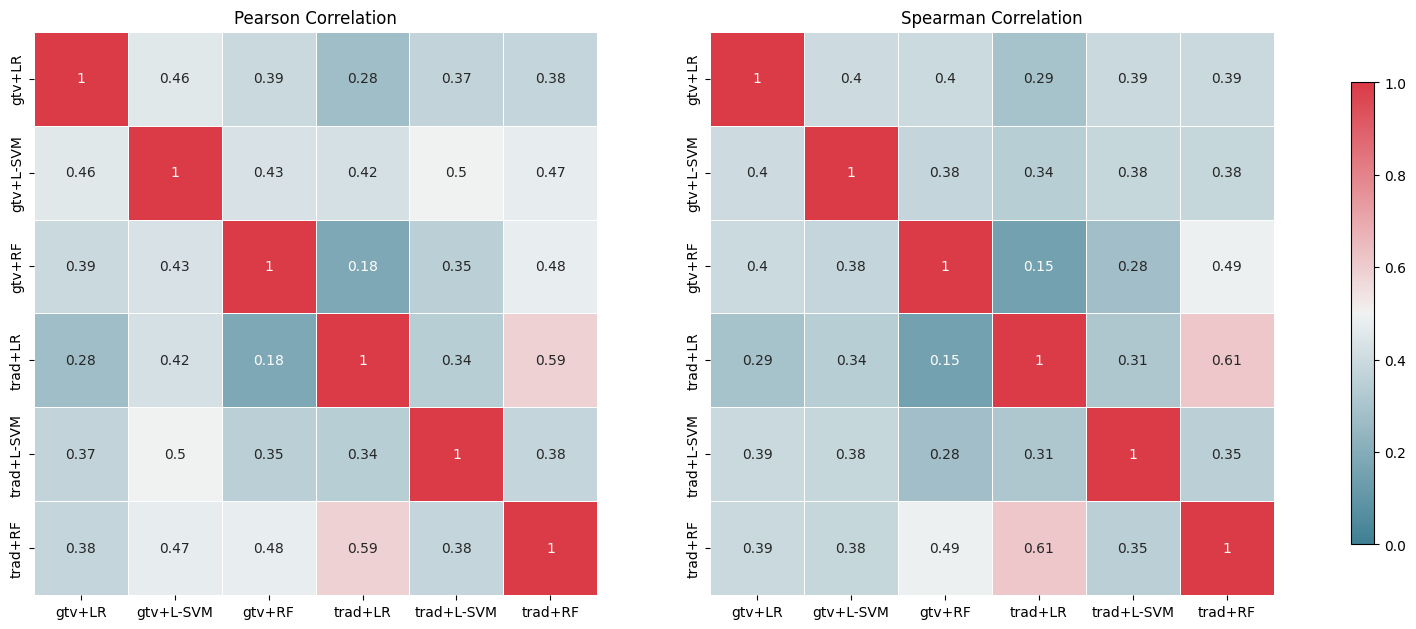

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# --- Left: Pearson ---
ax1 = axes[0]
hm1 = sns.heatmap(
    pearson_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax1
)
ax1.set_title("Pearson Correlation")


# --- Right: Spearman ---
ax2 = axes[1]
hm2 = sns.heatmap(
    spearman_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax2
)
ax2.set_title("Spearman Correlation")


# --- Add ONE shared colorbar ---
cbar = fig.colorbar(hm2.collections[0], ax=axes, shrink=0.75, location='right')
# cbar.set_label("Correlation", fontweight='bold')


plt.savefig("corr_plot.tif", format="tiff", dpi=600)
plt.show()


In [ ]:
import seaborn as sns
plt.figure(figsize=(20, 8))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

plt.subplot(1, 2, 1)
sns.heatmap(
    pearson_corr_df, cmap=cmap, square=True, linewidth=0.5,
    cbar_kws={'shrink': 0.75}, vmin=0, vmax=1, annot = True
)
plt.title("Pearson Correlation")
plt.xlabel("RadT", fontweight='bold')
plt.ylabel("GTV", fontweight='bold')

# --- Right: Spearman ---
plt.subplot(1, 2, 2)
sns.heatmap(
    spearman_corr_df, cmap=cmap, square=True, linewidth=0.5,
    cbar_kws={'shrink': 0.75}, vmin=0, vmax=1, annot=True
)
plt.title("Spearman Correlation")
plt.xlabel("RadT", fontweight='bold')
plt.ylabel("GTV", fontweight='bold')

plt.tight_layout()

plt.savefig("corr_plot.tif", format="tiff", dpi=600)

plt.show()

In [ ]:
_featuresGTV_df = featuresGTV_df.sort_values(by="pts_id").reset_index(drop=True)
_featuresTRAD_df = featuresTRAD_df.sort_values(by="pts_id").reset_index(drop=True)

In [ ]:
cross_val_predict(RandomForestClassifier(random_state=0), _featuresGTV_df[selected_signature["gtv"]["RandomForest"]], featuresGTV_df["PD"], cv=cv, method='predict_proba')[:,1]

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=False)
targets = _featuresGTV_df["PD"]
probs_gtv = cross_val_predict(RandomForestClassifier(random_state=0), _featuresGTV_df[selected_signature["gtv"]["RandomForest"]], featuresGTV_df["PD"], cv=cv, method="predict_proba")[:,1]
probs_trad = cross_val_predict(RandomForestClassifier(random_state=0), _featuresTRAD_df[selected_signature["trad"]["RandomForest"]], featuresGTV_df["PD"], cv=cv, method="predict_proba")[:,1]

compare_aucs(probs_gtv, probs_trad, targets)

In [ ]:
_featuresGTV_df

In [ ]:
# gtv
# **********
# Evaluating LR on gtv dataset...
# percentile ci: 0.7333333333333334 [0.59583333 0.91666667] 0.7689125
# bca ci: 0.7333333333333334 [0.5958333333333334, 0.9166666666666667]
# p_value: 0.014
# **********
# trad
# **********
# Evaluating LR on trad dataset...
# percentile ci: 0.7291666666666667 [0.50822917 0.875     ] 0.7210083333333334
# bca ci: 0.7291666666666667 [0.5083333333333334, 0.875]
# p_value: 0.012

In [ ]:

# for roi_name, value_dict in {"gtv":{"df":featuresGTV_df, "features":FILTERED_FEATURES_GTV}, "trad":{"df":featuresTRAD_df, "features":FILTERED_FEATURES_TRAD}}.items():
#     print("*"*10)
#     print(roi_name)
#     print("*"*10)
    
#     df = value_dict["df"]
#     features = value_dict["features"]
#     selected_features = mannwhitneyu(df, features, num_feats=5)
    
#     for model_name, model in models.items():
#         piped_model = make_pipeline(StandardScaler(), model)
#         print(f"Evaluating {model_name} on {roi_name} dataset...")
#         cv_aucs = cross_val_score(piped_model, df[selected_features], df["PD"], cv=5, scoring='roc_auc')
#         print(cv_aucs, cv_aucs.mean())
#         # results_sfs_GTV.append({
#         #     'Model': model_name,
#         #     'Selected Features': ', '.join(selected_features_GTV),
#         #     'AUC per fold': auc_sfs.tolist(),
#         #     'Media AUC': auc_sfs.mean()
#         # })
